**Netflix Data Exploration and Visualization Report**
---




**Overview:**

Netflix is one of the leading global streaming platforms, offering a wide range of movies and TV shows across different regions. This analysis aims to explore the dataset and derive insights that can help Netflix decide what type of content to produce and how to grow its business in different countries.

**Problem Statement:**
Analyze Netflix’s content dataset to:

1. Identify trends in movies vs TV shows
2. Understand content distribution across countries
3. Analyze genres, actors, and release patterns
4. Provide data-driven recommendations on:
   * What type of content Netflix should produce
   * How Netflix can grow in different countries

**Data Understanding and Preprocessing**

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df = pd.read_csv('netflix.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [102]:
df.shape

(8807, 12)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


**Observations:**
1. The dataset contains 8807 rows and 12 columns, representing movies and TV shows available on Netflix.
2. It consists primarily of categorical features, with a few numerical attributes such as release_year.
3. Columns like director, cast, country have missing values
4. date_added needs conversion to datetime
5. cast and listed_in columns have multiple strings which are comma separated. These need to be split and exploded for proper analysis
6. The duration column contains mixed formats:
Movies -> duration in minutes (e.g., "90 min").
TV Shows -> duration in seasons (e.g., "2 Seasons")
7. Netflix platform is movie-heavy. Indicates historical focus on movies over TV shows
8. Netflix collaborates with a large number of creators and actors.
9. US dominates content production.
10. Drama is dominant genre.
11. Majority content is recent

In [104]:
df['date_added']

,date_added
0,"September 25, 2021"
1,"September 24, 2021"
2,"September 24, 2021"
3,"September 24, 2021"
4,"September 24, 2021"
...,...
8802,"November 20, 2019"
8803,"July 1, 2019"
8804,"November 1, 2019"
8805,"January 11, 2020"


In [105]:
df['date_added'] = pd.to_datetime(df['date_added'])

ValueError: time data " August 4, 2017" doesn't match format "%B %d, %Y", at position 1442. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [106]:
df['date_added'] = df['date_added'].str.strip()

In [107]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [108]:
df['date_added'].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [109]:
df['date_added'].isna().sum()

np.int64(10)

The date_added column was cleaned by removing leading/trailing spaces and converted into datetime format. A small number of missing values (10 rows) were observed after conversion, which are negligible and do not significantly impact the analysis.

**Exploratory Data Analysis**

**Time-Based Analysis**

In [110]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [111]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [112]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,429


1. Netflix experienced a massive surge in content addition after 2015, with the number of titles increasing exponentially and peaking around 2019. This indicates a period of aggressive expansion and content acquisition.
2. Slight Decline After 2019

In [113]:
df_grouped = df.groupby(['year_added', 'type'])['title'].count().unstack()
df_grouped

type,Movie,TV Show
year_added,,
2008.0,1.0,1.0
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,13.0,NaN
2012.0,3.0,NaN
2013.0,6.0,5.0
2014.0,19.0,5.0
2015.0,56.0,26.0
2016.0,253.0,176.0


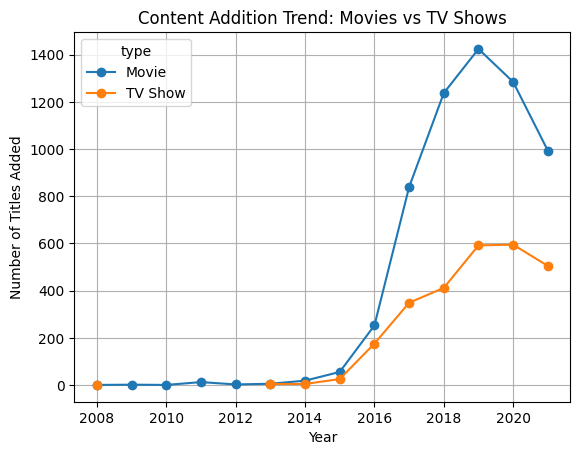

In [114]:
df_grouped.plot(kind='line', marker='o')

plt.title("Content Addition Trend: Movies vs TV Shows")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid()
plt.show()

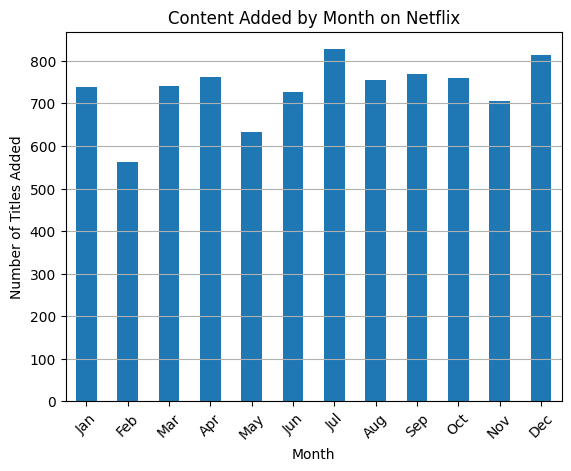

In [168]:
df.groupby('month_added')['type'].count().plot(kind='bar')

plt.title("Content Added by Month on Netflix")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")

plt.xticks(
    ticks=range(12),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=45
)

plt.grid(axis='y')
plt.show()

**Insights:**
1. The number of both movies and TV shows added to Netflix increased significantly after 2015, marking a clear turning point in the platform’s content strategy.
2. While movies dominate in terms of total volume, TV shows have shown consistent growth over the years.
3. The peak in content addition occurred around 2019 for both categories, after which a slight decline is observed in 2020 and 2021.
4. The distribution of content additions across months appears relatively uniform, indicating that Netflix does not rely on strong seasonal release patterns.

**Country-Based Analysis**

In [115]:
df[['country', 'listed_in', 'cast', 'director']].isna().sum()

,0
country,831
listed_in,0
cast,825
director,2634


In [116]:
(df[['country', 'listed_in', 'cast', 'director']].isna().sum() / len(df)) * 100

,0
country,9.435676
listed_in,0.000000
cast,9.367549
director,29.908028


**Insights:**
1. Missing value analysis shows that the director column has a high percentage of missing values (approx 30%), making it less reliable for detailed analysis.
2. The country and cast columns have moderate missing values (approx 9%), which can be handled by imputing with "Unknown" to avoid data loss.
3. The listed_in column has no missing values and is therefore highly reliable for further analysis.

In [117]:
df['country'] = df['country'].fillna('Unknown')
df['country'] = df['country'].str.split(',')

In [118]:
df['country'].head()

,country
0,[United States]
1,[South Africa]
2,[Unknown]
3,[Unknown]
4,[India]


In [119]:
df_country = df.explode('country')
df_country['country'] = df_country['country'].str.strip()
df_country

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,11.0
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,7.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,11.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,1.0


In [120]:
df_country['country'].value_counts()

,count
country,
United States,3690
India,1046
Unknown,831
United Kingdom,806
Canada,445
...,...
Sudan,1
Panama,1
Uganda,1


In [121]:
df_country['country'].value_counts().head(10)

,count
country,
United States,3690
India,1046
Unknown,831
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


**Insights:**
1. The United States contributes the highest number of titles on Netflix, significantly more than any other country.
2. India is the second-largest contributor to Netflix content.
- Huge opportunity market
- High content production
- Strong regional demand
3. Countries like the UK, Canada, France, Japan, and South Korea also contribute significantly
4. While the US dominates content production, the presence of multiple countries in the top contributors indicates Netflix’s strategy of expanding globally through localized and international content.

**Recommendations:**
1. Increase investment in Indian and other high-growth markets due to their strong contribution and audience base.
2. Expand content production in countries like South Korea, Japan, and Spain, where regional content has global appeal.
3. Diversify content sources to reduce reliance on US-based productions.

**Genre Analysis**

In [122]:
df['listed_in'] = df['listed_in'].str.split(',')

df_genre = df.explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()

In [124]:
df_genre.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[Unknown],2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021.0,9.0


In [126]:
top_genres = df_genre['listed_in'].value_counts().head(10)
top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


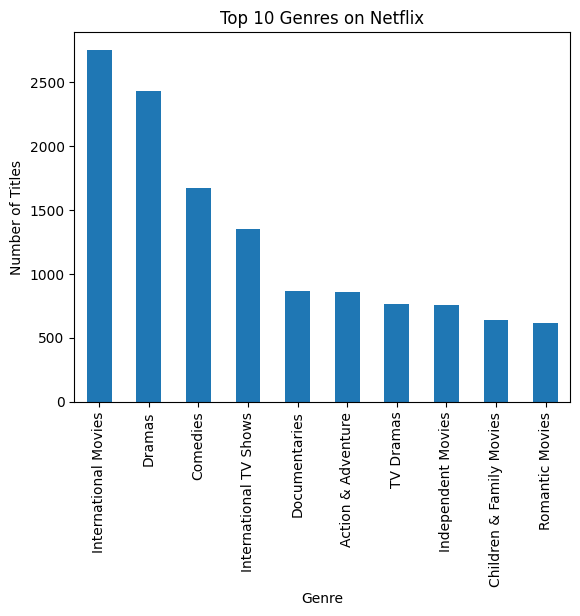

In [127]:
top_genres.plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
plt.show()

**Insight:**
1. Drama and Comedy being among the top genres indicates that these are consistently popular across audiences and should remain a core focus area for content production.

**Recommendations:**
1. Invest in International Content: Continue producing region-specific content for global expansion
2. Focus on Drama + Comedy: Safe, high-demand genres with wide audience appeal
3. Expand Hybrid Genres: (e.g., Romantic Comedy, Action Drama)

In [128]:
genre_type = df_genre.groupby(['listed_in', 'type']).size().unstack()
genre_type

type,Movie,TV Show
listed_in,,
Action & Adventure,859.0,NaN
Anime Features,71.0,NaN
Anime Series,NaN,176.0
British TV Shows,NaN,253.0
Children & Family Movies,641.0,NaN
Classic & Cult TV,NaN,28.0
Classic Movies,116.0,NaN
Comedies,1674.0,NaN
Crime TV Shows,NaN,470.0


In [129]:
genre_type = genre_type.fillna(0)
genre_type.head()

type,Movie,TV Show
listed_in,,
Action & Adventure,859.0,0.0
Anime Features,71.0,0.0
Anime Series,0.0,176.0
British TV Shows,0.0,253.0
Children & Family Movies,641.0,0.0


The NaN values observed after unstacking indicate that certain genres are exclusive to either movies or TV shows. These values were replaced with 0 to enable proper comparison and visualization.

In [130]:
top_genres = df_genre['listed_in'].value_counts().head(10).index
genre_type_top = genre_type.loc[top_genres]
genre_type_top

type,Movie,TV Show
listed_in,,
International Movies,2752.0,0.0
Dramas,2427.0,0.0
Comedies,1674.0,0.0
International TV Shows,0.0,1351.0
Documentaries,869.0,0.0
Action & Adventure,859.0,0.0
TV Dramas,0.0,763.0
Independent Movies,756.0,0.0
Children & Family Movies,641.0,0.0


<Axes: xlabel='listed_in'>

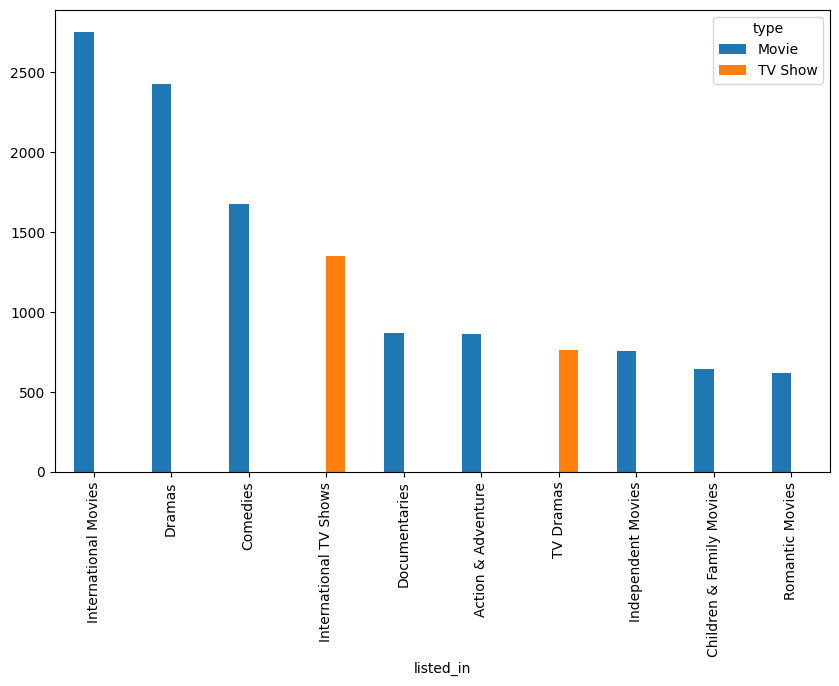

In [131]:
genre_type_top.plot(kind='bar', figsize=(10,6))

**Insights:**
1. The analysis indicates that genres are strongly aligned with specific content formats.
2. Most genres such as Drama, Comedy, and International content are dominated by movies, whereas genres like TV Dramas and International TV Shows are exclusive to TV series.
3. This suggests that Netflix strategically chooses content format based on the storytelling needs of the genre, using TV shows for long-form engagement and movies for standalone consumption.

**Recommendations:**
1. Increase investment in TV formats for drama and international storytelling to improve user retention
2. Maintain movie production in genres like comedy and action for broader audience appeal
3. Convert popular movie genres into TV formats (e.g., Comedy series, Action series)

**Rating Analysis**

In [132]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [133]:
df = df[~df['rating'].str.contains('min', na=False)]

A few incorrect entries in the rating column containing duration values (e.g., "74 min") were identified and removed to ensure accurate analysis.

In [134]:
rating_counts = df['rating'].value_counts()
rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


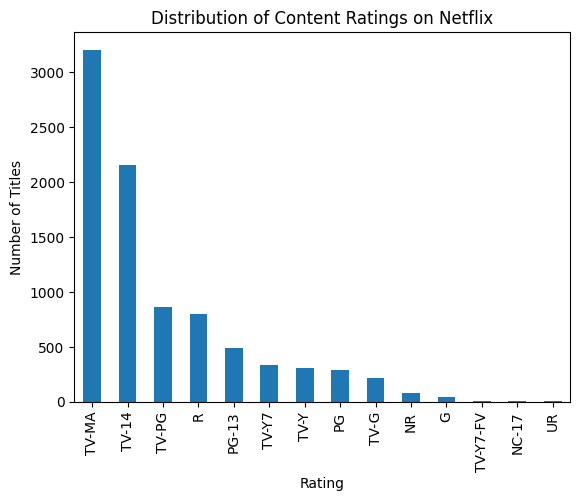

In [135]:
rating_counts.plot(kind='bar')

plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
plt.show()

In [136]:
rating_type = df.groupby(['rating', 'type']).size().unstack().fillna(0)
rating_type

type,Movie,TV Show
rating,,
G,41.0,0.0
NC-17,3.0,0.0
NR,75.0,5.0
PG,287.0,0.0
PG-13,490.0,0.0
R,797.0,2.0
TV-14,1427.0,733.0
TV-G,126.0,94.0
TV-MA,2062.0,1145.0


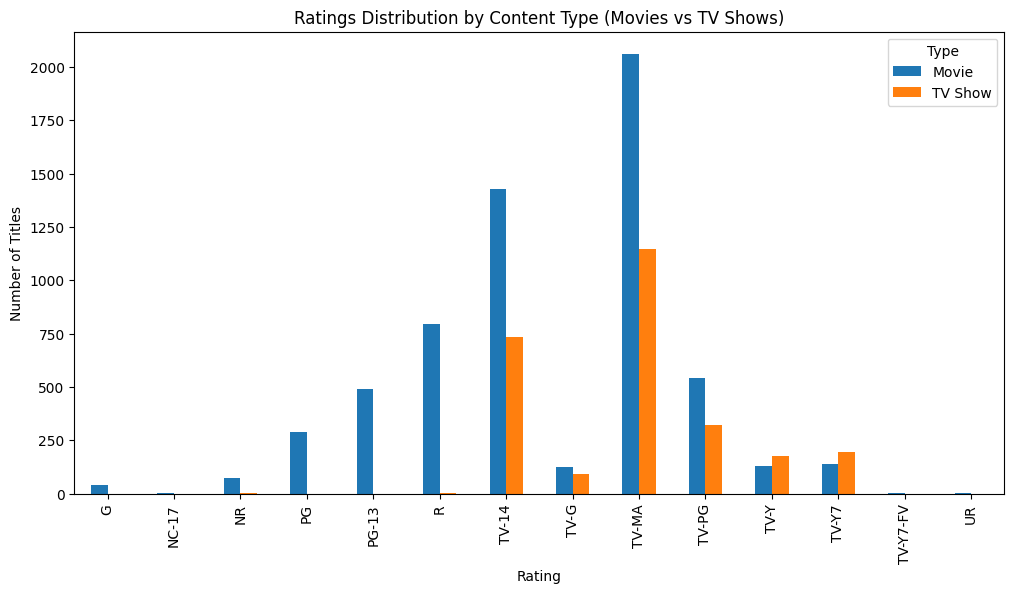

In [137]:
rating_type.plot(kind='bar', figsize=(12,6))

plt.title("Ratings Distribution by Content Type (Movies vs TV Shows)")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
plt.legend(title="Type")
plt.show()

**Insights:**
1. The majority of Netflix content falls under TV-MA and TV-14 categories, indicating a strong focus on adult and teenage audiences.
2. TV-style ratings dominate the platform, suggesting Netflix’s emphasis on streaming-oriented, episodic content.
3. In contrast, ratings such as TV-Y, TV-Y7, and G have significantly lower representation, indicating that children and family-oriented content is relatively underrepresented.

**Recommendations:**
1. Continue investing in mature and teen-focused content (TV-MA, TV-14), as it forms the majority of the platform’s engagement base.
2. Increase production of children and family-oriented content to tap into an underserved segment and broaden the subscriber base.

**Genre vs Country Analysis**

In [138]:
df_multi = df.explode('country').explode('listed_in')
df_multi['country'] = df_multi['country'].str.strip()
df_multi['listed_in'] = df_multi['listed_in'].str.strip()

In [139]:
df_multi.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021.0,9.0


In [140]:
top_countries = df_multi['country'].value_counts().head(5).index
top_countries

Index(['United States', 'India', 'United Kingdom', 'Unknown', 'France'], dtype='object', name='country')

In [141]:
df_top = df_multi[df_multi['country'].isin(top_countries)]
df_top

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...,2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,TV Action & Adventure,To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,Docuseries,"Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero...",2020.0,1.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,Comedies,"Dragged from civilian life, a former superhero...",2020.0,1.0
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,Dramas,A scrappy but poor boy worms his way into a ty...,2019.0,3.0
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,International Movies,A scrappy but poor boy worms his way into a ty...,2019.0,3.0


Entries with "Unknown" country were retained in the dataset to preserve data integrity but excluded from country-wise analysis, as they do not provide meaningful geographical insights.

In [142]:
df_top = df_top[df_top['country'] != 'Unknown']
df_top

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...,2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,Romantic TV Shows,In a city of coaching centers known to train I...,2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,TV Comedies,In a city of coaching centers known to train I...,2021.0,9.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,2021-09-24,1993,TV-MA,125 min,Dramas,"On a photo shoot in Ghana, an American model s...",2021.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero...",2020.0,1.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,Comedies,"Dragged from civilian life, a former superhero...",2020.0,1.0
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,Dramas,A scrappy but poor boy worms his way into a ty...,2019.0,3.0
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,International Movies,A scrappy but poor boy worms his way into a ty...,2019.0,3.0


In [143]:
genre_country = df_top.groupby(['country', 'listed_in']).size()
genre_country = genre_country.reset_index(name='count')
genre_country

,country,listed_in,count
0,France,Action & Adventure,37
1,France,British TV Shows,2
2,France,Children & Family Movies,23
3,France,Classic Movies,6
4,France,Comedies,51
...,...,...,...
144,United States,TV Sci-Fi & Fantasy,60
145,United States,TV Shows,4
146,United States,TV Thrillers,27
147,United States,Teen TV Shows,33


In [144]:
pivot = genre_country.pivot(index='country', columns='listed_in', values='count').fillna(0)
pivot

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
country,,,,,,,,,,,,,,,,,,,,,
France,37.0,0.0,0.0,2.0,23.0,0.0,6.0,51.0,23.0,2.0,...,6.0,24.0,27.0,3.0,2.0,1.0,0.0,3.0,0.0,44.0
India,137.0,0.0,0.0,3.0,26.0,0.0,11.0,323.0,9.0,5.0,...,5.0,26.0,28.0,7.0,2.0,3.0,3.0,3.0,1.0,92.0
United Kingdom,84.0,0.0,0.0,225.0,46.0,7.0,16.0,91.0,48.0,7.0,...,9.0,44.0,36.0,2.0,2.0,4.0,0.0,2.0,0.0,61.0
United States,404.0,7.0,18.0,24.0,390.0,17.0,81.0,680.0,145.0,52.0,...,94.0,258.0,232.0,37.0,51.0,60.0,4.0,27.0,33.0,292.0


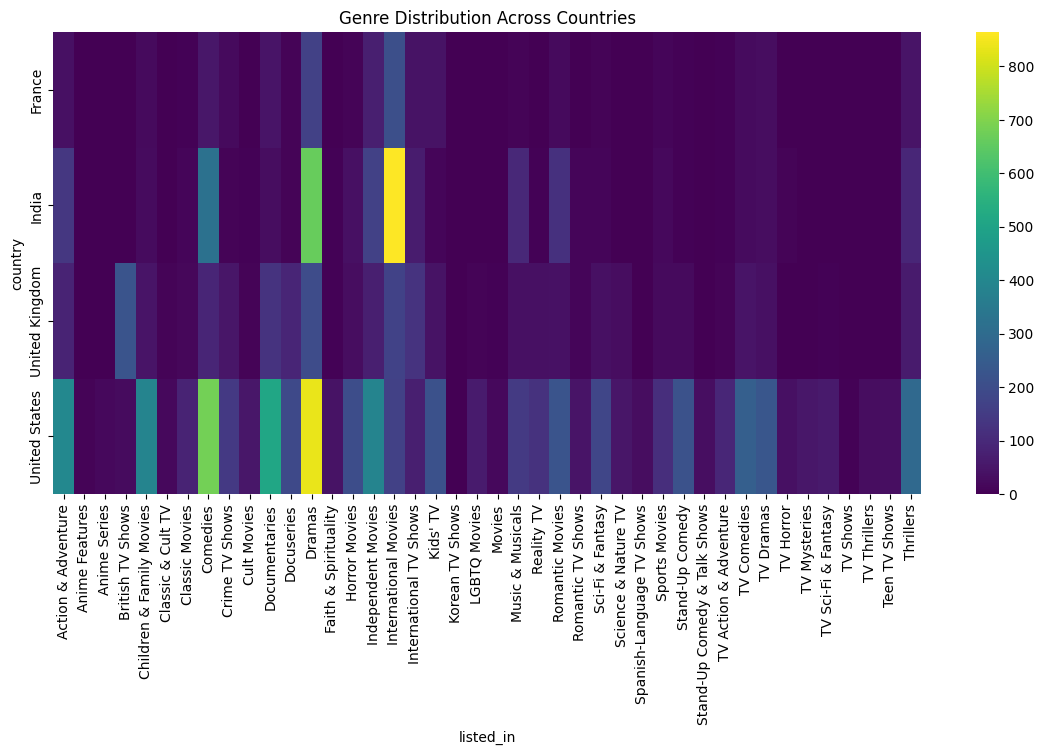

In [145]:
plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='viridis')

plt.title("Genre Distribution Across Countries")
plt.show()

**Insights:**
1. US has a diverse and dominant content library across almost all genres.
2. India focuses on specific high-demand genres such as comedies, dramas and international movies rather than broad diversity.
3. The United Kingdom stands out with a strong presence of region-specific genres like British TV Shows, reflecting localized content production.

**Recommendations:**
1. Netflix should adopt a region-specific content strategy by focusing on genres that perform well in individual countries while also expanding successful regional content globally.
2. Additionally, increasing investment in TV shows and underrepresented segments such as family content can further enhance user engagement and subscriber growth.

**Duration Analysis**

In [146]:
movies = df[df['type'] == 'Movie'].copy()
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0,9.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",[Unknown],2021-09-24,2021,PG,91 min,[Children & Family Movies],Equestria's divided. But a bright-eyed hero be...,2021.0,9.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","[United States, Ghana, Burkina Faso, United...",2021-09-24,1993,TV-MA,125 min,"[Dramas, Independent Movies, International M...","On a photo shoot in Ghana, an American model s...",2021.0,9.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",[United States],2021-09-24,2021,PG-13,104 min,"[Comedies, Dramas]",A woman adjusting to life after a loss contend...,2021.0,9.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","[Germany, Czech Republic]",2021-09-23,2021,TV-MA,127 min,"[Dramas, International Movies]",After most of her family is murdered in a terr...,2021.0,9.0


In [147]:
tv = df[df['type'] == 'TV Show'].copy()
tv.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV ...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, ...",In a city of coaching centers known to train I...,2021.0,9.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[TV Dramas, TV Horror, TV Mysteries]",The arrival of a charismatic young priest brin...,2021.0,9.0


In [148]:
movies['duration'] = movies['duration'].str.replace(' min', '')

In [149]:
movies['duration'] = movies['duration'].astype(int)

In [150]:
movies['duration']

,duration
0,90
6,91
7,125
9,104
12,127
...,...
8801,96
8802,158
8804,88
8805,88


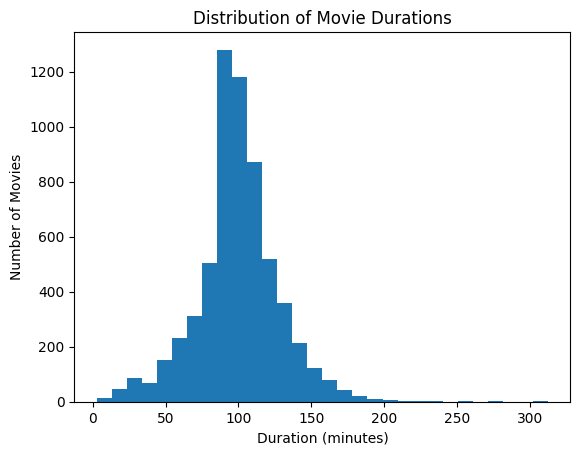

In [151]:
movies['duration'].plot(kind='hist', bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.show()

**Insight:**
1. The distribution of movie durations shows that most Netflix movies fall within the 80–120 minute range, with a peak around 90–100 minutes. This indicates a strong preference for medium-length content, while very short and very long movies are relatively uncommon.

**Recommendation:**
1. Netflix should continue producing movies within the 80–120 minute range, as this duration aligns well with audience consumption patterns. Longer formats can be selectively used for high-impact storytelling.

In [152]:
tv['duration'].head()

,duration
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons
5,1 Season


In [153]:
tv['seasons'] = tv['duration'].str.replace(' Seasons', '')
tv['seasons'] = tv['seasons'].str.replace(' Season', '')
tv['seasons'] = tv['seasons'].astype(int)

The duration column for TV Shows contained values in string format such as “1 Season” and “2 Seasons”. To enable numerical analysis, the text was cleaned by removing the words “Season” and “Seasons”, and the remaining values were converted into an integer column representing the number of seasons.

In [154]:
tv[['duration', 'seasons']]

,duration,seasons
1,2 Seasons,2
2,1 Season,1
3,1 Season,1
4,2 Seasons,2
5,1 Season,1
...,...,...
8795,2 Seasons,2
8796,2 Seasons,2
8797,3 Seasons,3
8800,1 Season,1


In [155]:
tv['seasons'].value_counts()

,count
seasons,
1,1793
2,425
3,199
4,95
5,65
6,33
7,23
8,17
9,9


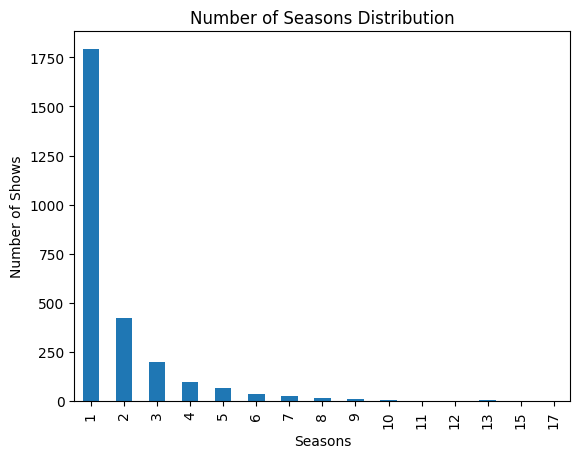

In [156]:
tv['seasons'].value_counts().sort_index().plot(kind='bar')

plt.title("Number of Seasons Distribution")
plt.xlabel("Seasons")
plt.ylabel("Number of Shows")
plt.show()

**Insight:**
1. The majority of TV shows on Netflix consist of only one season, with a sharp decline in the number of shows having multiple seasons. This indicates that Netflix tends to produce limited-series content rather than long-running shows.

**Recommendation:**
1. Netflix should continue investing in limited-series formats while selectively extending high-performing shows into multiple seasons to maximize engagement and retention.

**Cast Analysis**

In [157]:
df_cast = df.copy()
df_cast.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV ...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, ...",In a city of coaching centers known to train I...,2021.0,9.0


In [158]:
df_cast['cast'] = df_cast['cast'].fillna('Unknown')
df_cast['cast'] = df_cast['cast'].str.split(',')

In [159]:
df_cast = df_cast.explode('cast')
df_cast['cast'] = df_cast['cast'].str.strip()

In [160]:
df_cast.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,Gail Mabalane,[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,Thabang Molaba,[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",2021.0,9.0


In [161]:
# top actors
df_cast['cast'].value_counts().head(10)

,count
cast,
Unknown,825
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30


In [162]:
df_cast = df_cast[df_cast['cast'] != 'Unknown']
df_cast['cast'].value_counts().head(10)

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


**Insights:**
1. A significant portion of the dataset had missing cast information, which was handled during preprocessing.
2. After removing missing values, it was observed that no single actor dominates the dataset, although some actors appear more frequently. This indicates a diverse distribution of actors across Netflix content.

**Director Analysis**

In [163]:
df_director = df.copy()

In [164]:
df_director['director']

,director
0,Kirsten Johnson
1,NaN
2,Julien Leclercq
3,NaN
4,NaN
...,...
8802,David Fincher
8803,NaN
8804,Ruben Fleischer
8805,Peter Hewitt


In [165]:
df_director['director'] = df_director['director'].fillna('Unknown')
df_director.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV ...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,NaN,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, ...",In a city of coaching centers known to train I...,2021.0,9.0


In [166]:
df_director = df_director[df_director['director'] != 'Unknown']
df_director['director'].value_counts().head(10)

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Martin Scorsese,12
Youssef Chahine,12


**Insights:**
1. Netflix focuses on content diversity by working with multiple directors rather than relying on a few well-known names.
2. This observation aligns with the cast analysis, where no single actor dominated the dataset, further reinforcing Netflix’s strategy of diverse content creation.

**Recommendation:**
1. Netflix should continue investing in diverse directorial talent and strengthen collaborations across regions to support its global content strategy.

**Overall Business Insights:**
1. Netflix experienced rapid content expansion after 2015, indicating aggressive growth strategy.
2. Genre preferences differ across countries, showing that Netflix tailors content to regional audiences.
3. Drama, Comedy, and International content are consistently popular across regions.
4. Majority of content is aimed at adult and teenage viewers (TV-MA, TV-14).
Optimized Content Length
5. Movies are typically 80–120 minutes, and TV shows are mostly short-series (1–2 seasons).
6. Content production is heavily concentrated in countries like the US, India, and the UK.
7. No reliance on specific actors or directors; content is created by a broad pool of talent.

**Overall Recommendations:**
1. Invest in region-specific genres to cater to local audience preferences.
2. Continue producing medium-length movies and limited-series TV shows to maximize engagement and reduce risk.
3. Promote successful regional content to international audiences.
4. Increase investment in underrepresented categories such as children and family programming.
5. Continue prioritizing high-performing genres like Drama and Comedy while exploring niche categories.
6. Continue collaborating with a wide range of actors and directors globally.
7. Align content releases with peak engagement periods to maximize viewership.

**Conclusion:**

The analysis reveals that Netflix’s success is driven by a combination of localized content strategies, optimized content formats, and a diverse talent base. By continuing to focus on region-specific preferences, short-format content, and underexplored segments like family programming, Netflix can further strengthen its global presence and drive future growth.